# Analysis

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Load Data

In [2]:
bdf_raw = pd.read_csv("results.csv", sep=';', header=None, names=["algo", "buckets", "t", "t1", "t2", "t3", "t4", "t5"])
bdf_raw.head()

,algo,buckets,t,t1,t2,t3,t4,t5
0,sort_1,100000,2.273125,0.101698,0.635090,1.359729,0.020603,NaN
1,sort_1,35000,2.475707,0.102941,0.648740,1.625841,0.021095,NaN
2,sort_1,50000,2.482652,0.102780,0.709927,1.542029,0.022661,NaN
3,sort_1,20000,2.500448,0.102594,0.581902,1.751759,0.018015,NaN
4,sort_1,8000,2.585771,0.102740,0.477317,1.966189,0.015851,NaN


In [3]:
bdf = bdf_raw.groupby(['algo', 'buckets']).agg(
    t_mean=('t', 'mean'), t_std=('t', 'std'),
    t1_mean=('t1', 'mean'), t1_std=('t1', 'std'),
    t2_mean=('t2', 'mean'), t2_std=('t2', 'std'),
    t3_mean=('t3', 'mean'), t3_std=('t3', 'std'),
    t4_mean=('t4', 'mean'), t4_std=('t4', 'std'),
    t5_mean=('t5', 'mean'), t5_std=('t5', 'std')
).reset_index()

bdf.head()

,algo,buckets,t_mean,t_std,t1_mean,t1_std,t2_mean,t2_std,t3_mean,t3_std,t4_mean,t4_std,t5_mean,t5_std
0,sort_1,1,4.690597,NaN,0.104152,NaN,0.285477,NaN,4.286540,NaN,0.014200,NaN,NaN,NaN
1,sort_1,100,3.502285,NaN,0.102578,NaN,0.338521,NaN,3.041414,NaN,0.015046,NaN,NaN,NaN
2,sort_1,1000,2.963605,NaN,0.102891,NaN,0.357437,NaN,2.477777,NaN,0.015244,NaN,NaN,NaN
3,sort_1,5000,2.651663,NaN,0.102896,NaN,0.429910,NaN,2.086665,NaN,0.015113,NaN,NaN,NaN
4,sort_1,6000,2.626301,NaN,0.102552,NaN,0.437863,NaN,2.049663,NaN,0.016628,NaN,NaN,NaN


# Buckets parameter analysis

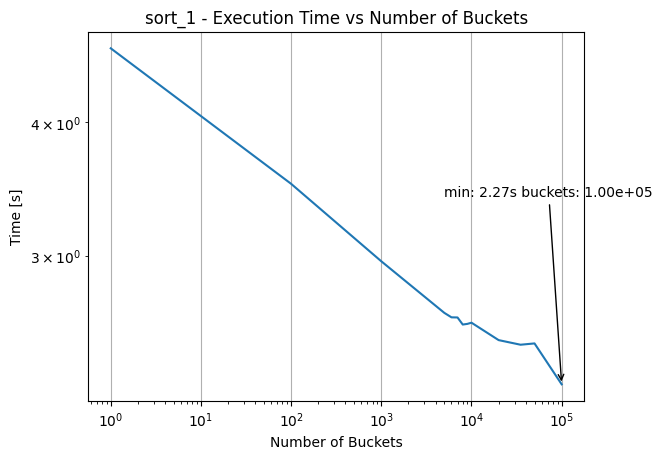

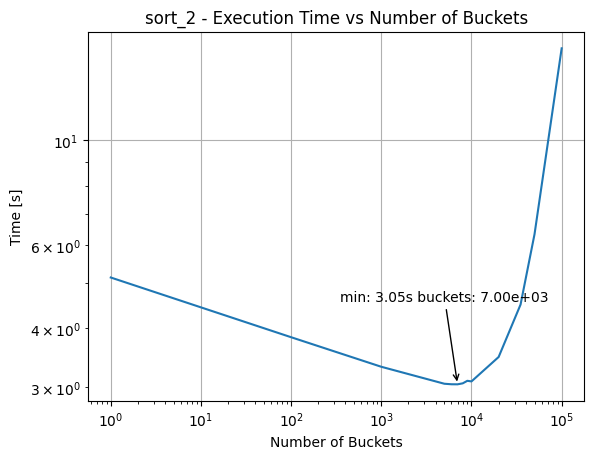

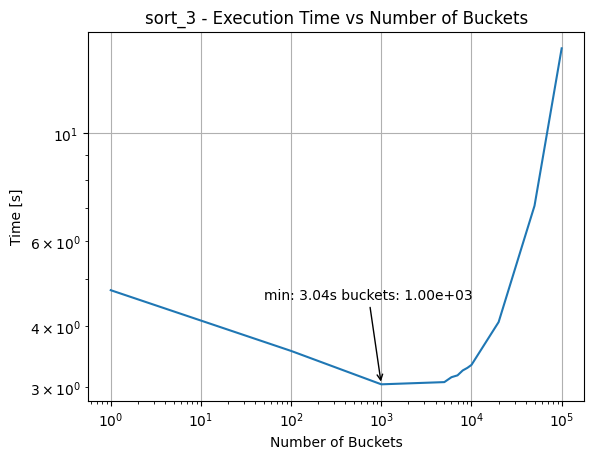

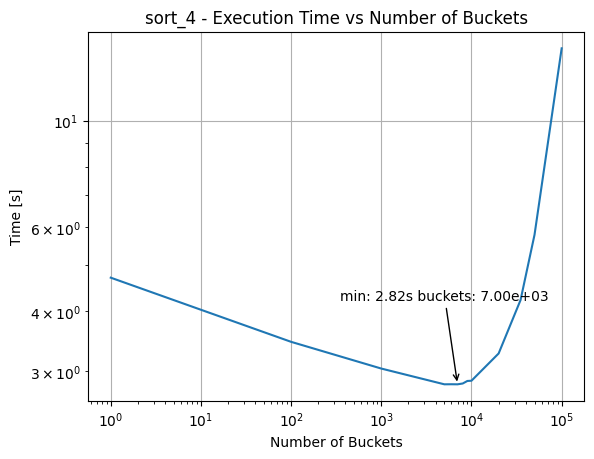

In [5]:
bucket_params = {}

for series in bdf.groupby(["algo"]):
    series_df = series[1]
    series_nm = series[0][0]
 
    plt.plot(series_df["buckets"], series_df["t_mean"], label="total execution")
    
    plt.title(f"{series_nm} - Execution Time vs Number of Buckets")
    # plt.legend()
    plt.xlabel("Number of Buckets")
    plt.ylabel("Time [s]")
    plt.yscale("log")
    plt.xscale("log")
    plt.grid()

    min_index = series_df["t_mean"].idxmin()
    min_value = series_df["t_mean"].min()

    min_index_label = series_df["t_mean"].idxmin()
    min_value = series_df["t_mean"].min()
    min_index_pos = series_df.index.get_loc(min_index_label)
    try:
        min_buckets = series_df["buckets"].iloc[min_index_pos]
    except IndexError:
        min_buckets = series_df["buckets"].iloc[min_index_pos]

    plt.annotate(f"min: {min_value:.2f}s buckets: {min_buckets:.2e}", xy=(min_buckets, min_value), xytext=(min_buckets*0.05, min_value*1.5),
                     arrowprops=dict(facecolor='black', arrowstyle='->'))
    
    bucket_params[series_nm] = min_buckets

    plt.show()

In [6]:
bucket_params

{'sort_1': np.int64(100000),
 'sort_2': np.int64(7000),
 'sort_3': np.int64(1000),
 'sort_4': np.int64(7000)}